# Multi-Dataset Diagnostic Plots

Side-by-side comparison of **CRC / Lung / Pancreas** Multi-Task LoRA gene-expression prediction.

Three diagnostics:
1. **Variance calibration** — per-gene `std(pred)` vs `std(true)` on test set. Reveals shrinkage / inversion.
2. **Mean calibration** — per-gene `mean(pred)` vs `mean(true)` on test set. Reveals systematic bias.
3. **Spatial split layout** — train / val / test cells on the slide, with the 4 held-out test tiles highlighted.

All three datasets use `top400` genes selected by variance with `min_coverage=0.1` on the training split (seed 42).


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# --- Style: Nature-ish, open axes, frameless legends, editable text in PDF ---
sns.set_theme(style="white", context="paper", font_scale=1.1)
mpl.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titleweight':  'bold',
    'legend.frameon':    False,
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
    'figure.dpi':        110,
    'savefig.dpi':       200,
})

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')
SEED    = 42
TOPN    = 400
MIN_COV = 0.1

# Optional: save figures (PDF + PNG) under PROJECT/figures/
SAVE_FIGS = True
FIG_DIR   = PROJECT / 'figures' / 'multi_dataset_diagnostics'
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

CONFIGS = {
    'crc':      {'exp_dir': PROJECT / 'experiments' / 'lora_probing_crc_multi_10.0x_mse',
                 'cache_dir': PROJECT / 'cache_crc'},
    'lung':     {'exp_dir': PROJECT / 'experiments' / 'lora_probing_lung_multi_10.0x_mse',
                 'cache_dir': PROJECT / 'cache_lung'},
    'pancreas': {'exp_dir': PROJECT / 'experiments' / 'lora_probing_pancreas_top400_multi_10.0x_mse_seed42',
                 'cache_dir': PROJECT / 'cache_pancreas'},
}

# Consistent dataset ordering and palette
ORDER       = ['crc', 'lung', 'pancreas']
SPLIT_COLOR = {'train': '#4A90D9', 'val': '#F5A623', 'test': '#D0021B'}

print('Setup complete.')
print(f'Datasets: {ORDER}')
print(f'Save figures to: {FIG_DIR if SAVE_FIGS else "(disabled)"}')


Setup complete.
Datasets: ['crc', 'lung', 'pancreas']
Save figures to: /hpc/group/jilab/tc459/MorphPT/figures/multi_dataset_diagnostics


In [2]:
def reproduce_all_meta(meta):
    """Reproduce the concatenated meta ordering used inside the training script.

    Training does:
        for spl in ["train", "val", "test"]:
            df_spl = meta[meta["split"] == spl].copy()
            all_meta_ordered.append(df_spl)
        all_meta = pd.concat(...).reset_index(drop=True)
    """
    parts = []
    for spl in ["train", "val", "test"]:
        parts.append(meta[meta["split"] == spl].copy())
    return pd.concat(parts, axis=0).reset_index(drop=True)


def reconstruct_splits(all_meta, seed=42, n_test_tiles=4, val_frac=0.1):
    """Replay the seed-determined split logic from the training script."""
    np.random.seed(seed)
    unique_tiles = all_meta['tile_id'].unique()
    test_tiles   = np.random.choice(unique_tiles, size=n_test_tiles, replace=False)
    test_mask    = all_meta['tile_id'].isin(test_tiles).values
    test_idx     = np.where(test_mask)[0]
    train_pool   = np.where(~test_mask)[0]
    np.random.shuffle(train_pool)
    n_val        = int(len(train_pool) * val_frac)
    val_idx      = train_pool[:n_val]
    train_idx    = train_pool[n_val:]
    return train_idx, val_idx, test_idx, test_tiles


def load_dataset(name, cfg, seed=42, topn=400, min_cov=0.1):
    """Load predictions, gene stats, meta, and splits for one dataset."""
    out = {'name': name, **cfg, 'seed': seed}

    # 1. Predictions on test
    yt = cfg['exp_dir'] / f'test_y_true_seed_{seed}.npy'
    yp = cfg['exp_dir'] / f'test_y_pred_seed_{seed}.npy'
    out['y_true'] = np.load(yt) if yt.exists() else None
    out['y_pred'] = np.load(yp) if yp.exists() else None

    # 2. Per-seed mean test r (for sanity)
    info = cfg['exp_dir'] / f'seed_{seed}_info.json'
    out['info'] = json.loads(info.read_text()) if info.exists() else None

    # 3. Per-gene results CSV
    res = cfg['exp_dir'] / 'multi_lora_hybrid_results.csv'
    out['df_res'] = pd.read_csv(res) if res.exists() else None

    # 4. Gene-stats CSV (variance, coverage on training split)
    gcsv = cfg['cache_dir'] / 'per_gene' / f'top{topn}_variance_mincov{min_cov}_train_seed{seed}.csv'
    out['df_stats'] = pd.read_csv(gcsv) if gcsv.exists() else None

    # 5. Merge + add per-gene stats from y_true / y_pred
    if out['df_res'] is not None and out['df_stats'] is not None:
        df = pd.merge(out['df_res'], out['df_stats'], on=['gene_idx', 'gene_name'], how='inner')
        if out['y_true'] is not None:
            # df rows are aligned with df_res; df_res rows are aligned with prediction columns
            # We need to map gene_idx -> column position in y_true/y_pred
            col_idx = {g: i for i, g in enumerate(out['df_res']['gene_idx'].values)}
            cols = df['gene_idx'].map(col_idx).values
            df['true_std_z']  = out['y_true'][:, cols].std(axis=0)
            df['pred_std_z']  = out['y_pred'][:, cols].std(axis=0)
            df['true_mean_z'] = out['y_true'][:, cols].mean(axis=0)
            df['pred_mean_z'] = out['y_pred'][:, cols].mean(axis=0)
        out['df'] = df
    else:
        out['df'] = None

    # 6. Meta + splits (for spatial plot)
    mp = cfg['cache_dir'] / 'meta.csv'
    if mp.exists():
        out['all_meta'] = reproduce_all_meta(pd.read_csv(mp))
    else:
        out['all_meta'] = None

    sp = cfg['exp_dir'] / f'splits_seed_{seed}.npz'
    if sp.exists():
        z = np.load(sp)
        out['train_idx'] = z['train_idx']
        out['val_idx']   = z['val_idx']
        out['test_idx']  = z['test_idx']
        out['test_tiles'] = z['test_tiles']
        out['splits_source'] = 'loaded'
    elif out['all_meta'] is not None:
        ti, vi, ei, tt = reconstruct_splits(out['all_meta'], seed=seed)
        out['train_idx'] = ti
        out['val_idx']   = vi
        out['test_idx']  = ei
        out['test_tiles'] = tt
        out['splits_source'] = 'reconstructed'
    else:
        out['splits_source'] = 'missing'

    return out


In [3]:
data = {}
for name in ORDER:
    cfg = CONFIGS[name]
    print(f'\n── Loading {name.upper()} ──')
    d = load_dataset(name, cfg, seed=SEED, topn=TOPN, min_cov=MIN_COV)
    data[name] = d

    if d['df'] is None:
        print(f'  ⚠️  Missing files (df_res or df_stats); rest of notebook will skip this dataset.')
        continue
    n_test, n_genes = d['y_true'].shape
    print(f'  Test cells   : {n_test:,}')
    print(f'  Num genes    : {n_genes}')
    print(f'  Mean test r  : {d["df"]["test_pearson_s42"].mean():.4f}')
    if d.get('train_idx') is not None:
        print(f'  Splits       : train={len(d["train_idx"]):,} | val={len(d["val_idx"]):,} | test={len(d["test_idx"]):,}  '
              f'({d["splits_source"]})')
        print(f'  Test tiles   : {list(d["test_tiles"])}')
    if d['all_meta'] is not None:
        print(f'  Meta cols    : {list(d["all_meta"].columns)}')



── Loading CRC ──
  Test cells   : 26,659
  Num genes    : 400
  Mean test r  : 0.3218
  Splits       : train=143,007 | val=15,889 | test=26,659  (loaded)
  Test tiles   : [np.int64(17), np.int64(19), np.int64(10), np.int64(3)]
  Meta cols    : ['cell_id', 'x_centroid', 'y_centroid', 'mmap_idx', 'x_bin', 'y_bin', 'tile_id', 'split']

── Loading LUNG ──
  Test cells   : 18,219
  Num genes    : 400
  Mean test r  : 0.0225
  Splits       : train=90,774 | val=10,085 | test=18,219  (loaded)
  Test tiles   : [np.int64(7), np.int64(14), np.int64(0), np.int64(13)]
  Meta cols    : ['cell_id', 'x_centroid', 'y_centroid', 'mmap_idx', 'x_bin', 'y_bin', 'tile_id', 'split']

── Loading PANCREAS ──
  Test cells   : 7,361
  Num genes    : 400
  Mean test r  : 0.1087
  Splits       : train=14,053 | val=1,561 | test=7,361  (loaded)
  Test tiles   : [np.int64(15), np.int64(11), np.int64(0), np.int64(3)]
  Meta cols    : ['cell_id', 'x_centroid', 'y_centroid', 'mmap_idx', 'x_bin', 'y_bin', 'tile_id', 's

## Cross-dataset summary

Mean Pearson r overall, in top-N (sorted by R) and top-N (sorted by training-set variance).
The gap between *Top-N by R* and *Top-N by Var* tells you whether the model is finding genes that are *predictable* (good) versus simply finding the most highly-variable ones (which would mean it's not using image information beyond what variance trivially predicts).


In [4]:
rows = []
for name in ORDER:
    d = data[name]
    if d['df'] is None:
        continue
    df = d['df']
    df_r   = df.sort_values('test_pearson_s42', ascending=False)
    df_var = df.sort_values('variance',         ascending=False)

    rec = {'Dataset': name.upper(),
           'N_test_cells': len(d['y_true']),
           'N_genes': len(df),
           'Mean R (all)': df['test_pearson_s42'].mean()}
    for k in [10, 20, 50, 100]:
        if k <= len(df):
            rec[f'Top{k} byR']   = df_r.head(k)['test_pearson_s42'].mean()
            rec[f'Top{k} byVar'] = df_var.head(k)['test_pearson_s42'].mean()
    rows.append(rec)

summary = pd.DataFrame(rows).set_index('Dataset')
display(summary.round(4))


,N_test_cells,N_genes,Mean R (all),Top10 byR,Top10 byVar,Top20 byR,Top20 byVar,Top50 byR,Top50 byVar,Top100 byR,Top100 byVar
Dataset,,,,,,,,,,,
CRC,26659,400,0.3218,0.7798,0.7628,0.7066,0.6463,0.6040,0.5226,0.5128,0.4406
LUNG,18219,400,0.0225,0.0813,0.0649,0.0671,0.0510,0.0522,0.0391,0.0426,0.0340
PANCREAS,7361,400,0.1087,0.6884,0.3119,0.5987,0.2814,0.4122,0.2025,0.2833,0.1714


## 1. Variance calibration

Each point = one gene. Color = test Pearson r. Size = train coverage.

**Key diagnostic**: the slope of the blue best-fit line.
- `slope ≈ 1.0`  → predictions match the variance scale of biology (ideal)
- `0 < slope < 1` → shrinkage to the mean (typical regression behaviour, but recoverable with calibration)
- `slope ≤ 0`    → model variance is **uncorrelated or anti-correlated** with biological variance — the model has not learned anything about per-gene variation


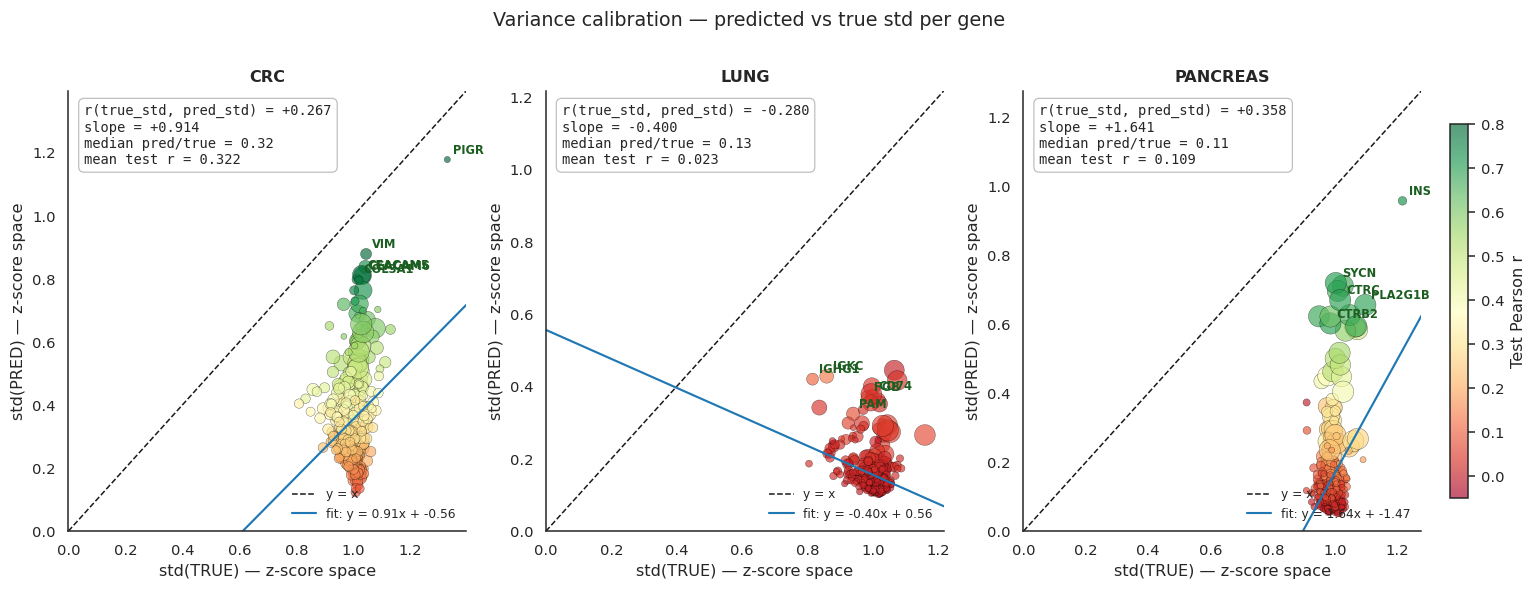

In [5]:
def _scatter_calibration(ax, df, x, y, vmin=-0.05, vmax=0.8, annotate_top=5):
    cov  = df['coverage']
    sizes = 15 + (cov - cov.min()) / (cov.max() - cov.min() + 1e-9) * 180
    sc = ax.scatter(df[x], df[y],
                    c=df['test_pearson_s42'], cmap='RdYlGn',
                    vmin=vmin, vmax=vmax,
                    s=sizes, alpha=0.65,
                    edgecolor='black', lw=0.25, rasterized=True)
    return sc

datasets_with_df = [n for n in ORDER if data[n]['df'] is not None]
n = len(datasets_with_df)

fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5.2), sharey=False)
if n == 1: axes = [axes]
sc = None

for ax, name in zip(axes, datasets_with_df):
    d  = data[name]
    df = d['df']

    sc = _scatter_calibration(ax, df, 'true_std_z', 'pred_std_z')

    lim_max = max(df['true_std_z'].max(), df['pred_std_z'].max()) * 1.05
    lims = (0, lim_max)
    ax.plot(lims, lims, 'k--', lw=1.0, label='y = x')

    coef = np.polyfit(df['true_std_z'], df['pred_std_z'], 1)
    xs   = np.array(lims)
    ax.plot(xs, coef[0] * xs + coef[1], color='#1f77b4', lw=1.4,
            label=f'fit: y = {coef[0]:.2f}x + {coef[1]:.2f}')

    r_std, _   = stats.pearsonr(df['true_std_z'], df['pred_std_z'])
    shrink_med = float(np.median(df['pred_std_z'] / df['true_std_z']))

    txt = (f"r(true_std, pred_std) = {r_std:+.3f}\n"
           f"slope = {coef[0]:+.3f}\n"
           f"median pred/true = {shrink_med:.2f}\n"
           f"mean test r = {df['test_pearson_s42'].mean():.3f}")
    ax.text(0.04, 0.97, txt, transform=ax.transAxes, va='top', ha='left',
            fontsize=9, family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#bbbbbb', alpha=0.95))

    # Annotate top-r genes
    for _, row in df.nlargest(5, 'test_pearson_s42').iterrows():
        ax.annotate(row['gene_name'],
                    (row['true_std_z'], row['pred_std_z']),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=7.5, color='#1b5e20', fontweight='bold')

    ax.set_xlabel('std(TRUE) — z-score space')
    ax.set_ylabel('std(PRED) — z-score space')
    ax.set_title(name.upper())
    ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
    ax.legend(loc='lower right', fontsize=8)

# Shared colorbar on the right
cbar = fig.colorbar(sc, ax=axes, fraction=0.018, pad=0.02, shrink=0.85)
cbar.set_label('Test Pearson r')

fig.suptitle('Variance calibration — predicted vs true std per gene',
             fontsize=12.5, y=1.02)

if SAVE_FIGS:
    fig.savefig(FIG_DIR / 'variance_calibration_3datasets.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / 'variance_calibration_3datasets.png', bbox_inches='tight')
plt.show()


## 2. Mean calibration

Each point = one gene. Color = test Pearson r. Size = train coverage.

Since data is z-scored on the training distribution, both axes should sit near 0 — but per-gene deviations on the test set matter:
- `bias = mean(pred − true)` measures global up/down shift
- `slope ≈ 1` over the y=x line means per-gene means are tracked correctly
- A flat horizontal cloud means the model collapses every gene to a constant — a strong indicator the head is essentially predicting a population average


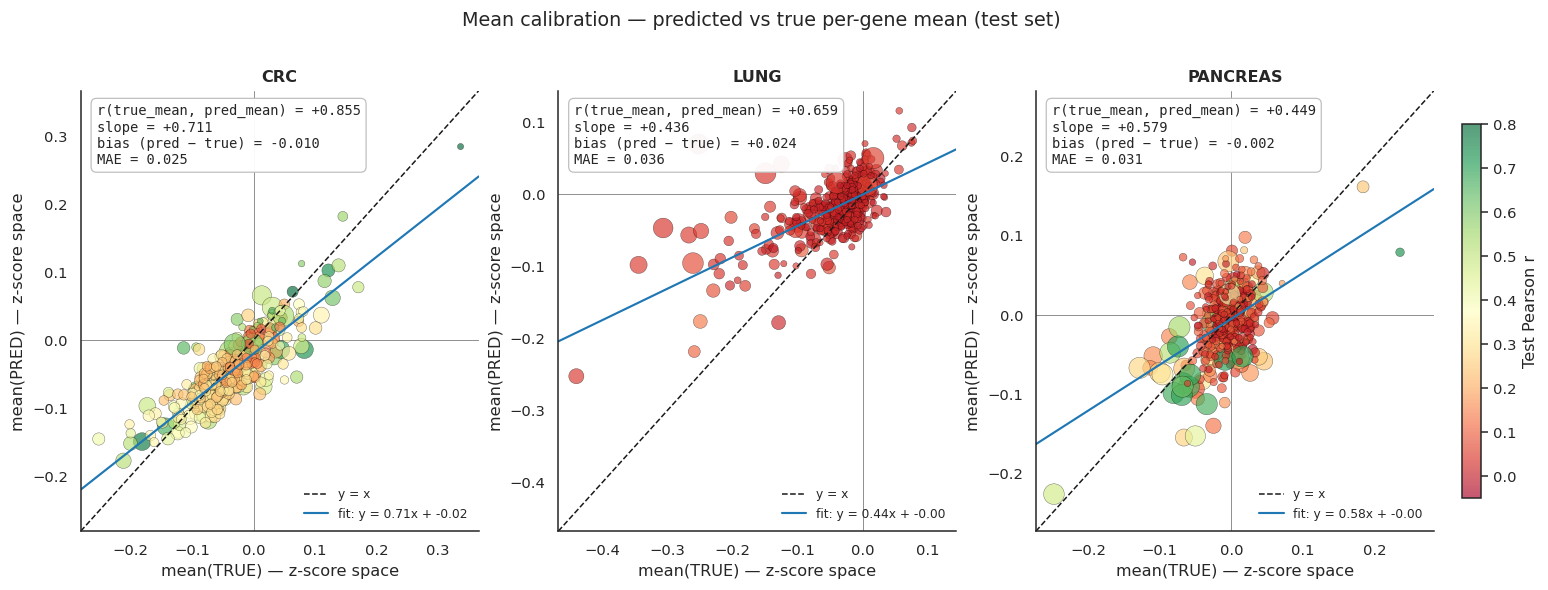

In [6]:
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5.2), sharey=False)
if n == 1: axes = [axes]
sc = None

for ax, name in zip(axes, datasets_with_df):
    d  = data[name]
    df = d['df']

    sc = _scatter_calibration(ax, df, 'true_mean_z', 'pred_mean_z')

    xy_min = min(df['true_mean_z'].min(), df['pred_mean_z'].min())
    xy_max = max(df['true_mean_z'].max(), df['pred_mean_z'].max())
    pad    = 0.05 * (xy_max - xy_min + 1e-9)
    lims   = (xy_min - pad, xy_max + pad)

    ax.plot(lims, lims, 'k--', lw=1.0, label='y = x')
    ax.axhline(0, color='#888', lw=0.6, zorder=0)
    ax.axvline(0, color='#888', lw=0.6, zorder=0)

    coef = np.polyfit(df['true_mean_z'], df['pred_mean_z'], 1)
    xs   = np.array(lims)
    ax.plot(xs, coef[0] * xs + coef[1], color='#1f77b4', lw=1.4,
            label=f'fit: y = {coef[0]:.2f}x + {coef[1]:.2f}')

    r_mean, _ = stats.pearsonr(df['true_mean_z'], df['pred_mean_z'])
    bias = float((df['pred_mean_z'] - df['true_mean_z']).mean())
    mae  = float((df['pred_mean_z'] - df['true_mean_z']).abs().mean())

    txt = (f"r(true_mean, pred_mean) = {r_mean:+.3f}\n"
           f"slope = {coef[0]:+.3f}\n"
           f"bias (pred − true) = {bias:+.3f}\n"
           f"MAE = {mae:.3f}")
    ax.text(0.04, 0.97, txt, transform=ax.transAxes, va='top', ha='left',
            fontsize=9, family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#bbbbbb', alpha=0.95))

    ax.set_xlabel('mean(TRUE) — z-score space')
    ax.set_ylabel('mean(PRED) — z-score space')
    ax.set_title(name.upper())
    ax.set_xlim(*lims); ax.set_ylim(*lims)
    ax.legend(loc='lower right', fontsize=8)

cbar = fig.colorbar(sc, ax=axes, fraction=0.018, pad=0.02, shrink=0.85)
cbar.set_label('Test Pearson r')

fig.suptitle('Mean calibration — predicted vs true per-gene mean (test set)',
             fontsize=12.5, y=1.02)

if SAVE_FIGS:
    fig.savefig(FIG_DIR / 'mean_calibration_3datasets.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / 'mean_calibration_3datasets.png', bbox_inches='tight')
plt.show()


## 3. Spatial split layout

Train / val / test cells plotted in slide coordinates.

The 4 held-out **test tiles** are entire spatial regions; val is 10% of the remaining cells (random); train is the rest.
Test tile bounding boxes are drawn in red.

**What to look for**:
- Are the 4 test tiles spatially **clustered** (concerning — they probe a single region) or **dispersed** (good)?
- Is val truly scattered across the training region (it should be, since val is random)?
- Does cell **density** look comparable inside vs outside the test tiles? Big density differences hint at tissue/tile heterogeneity that could explain dataset-specific failures.


In [7]:
COORD_CANDIDATES = [
    ('x', 'y'),
    ('cell_x', 'cell_y'),
    ('pixel_x', 'pixel_y'),
    ('centroid_x', 'centroid_y'),
    ('x_centroid', 'y_centroid'),
    ('center_x', 'center_y'),
    ('global_x', 'global_y'),
    ('x_pixel', 'y_pixel'),
    ('px', 'py'),
]
SLIDE_CANDIDATES = ['slide_id', 'sample_id', 'section_id', 'slide', 'sample', 'patient_id']


def find_coord_cols(meta):
    for xc, yc in COORD_CANDIDATES:
        if xc in meta.columns and yc in meta.columns:
            return xc, yc
    return None, None


def find_slide_col(meta):
    for c in SLIDE_CANDIDATES:
        if c in meta.columns:
            return c
    return None


def plot_spatial_layout(d, title=None, max_panels_per_row=4, panel_size=4.5):
    name = d['name']
    if d['all_meta'] is None or d.get('train_idx') is None:
        print(f'[{name}] meta or splits not available — skipping')
        return None

    meta = d['all_meta'].copy()
    xc, yc = find_coord_cols(meta)
    if xc is None:
        print(f'[{name}] could not find coordinate columns. Available: {list(meta.columns)}')
        return None
    slide_col = find_slide_col(meta)

    # Mark splits
    split = np.full(len(meta), 'unknown', dtype=object)
    split[d['train_idx']] = 'train'
    split[d['val_idx']]   = 'val'
    split[d['test_idx']]  = 'test'
    meta['final_split'] = split

    # Decide faceting
    if slide_col is not None and meta[slide_col].nunique() > 1:
        slides = sorted(meta[slide_col].unique())
    else:
        slide_col = None
        slides    = [None]

    n_slides = len(slides)
    n_cols   = min(n_slides, max_panels_per_row)
    n_rows   = int(np.ceil(n_slides / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(panel_size * n_cols, panel_size * n_rows),
                              squeeze=False)

    test_tile_set = set(int(t) for t in d['test_tiles'])

    for idx, slide in enumerate(slides):
        ax = axes[idx // n_cols][idx % n_cols]
        sub = meta if slide is None else meta[meta[slide_col] == slide]

        # Plot in order: train (background) → val → test (top)
        for s_name, sz, alpha in [('train', 1.5, 0.25),
                                   ('val',   3.0, 0.85),
                                   ('test',  2.0, 0.55)]:
            m = sub['final_split'] == s_name
            if m.sum() == 0:
                continue
            ax.scatter(sub.loc[m, xc], sub.loc[m, yc],
                       c=SPLIT_COLOR[s_name], s=sz, alpha=alpha,
                       label=f'{s_name} (n={m.sum():,})',
                       linewidths=0, rasterized=True)

        # Bounding boxes around test tiles within this slide
        for tid in test_tile_set:
            tile_cells = sub[sub['tile_id'] == tid]
            if len(tile_cells) == 0:
                continue
            x_min, x_max = tile_cells[xc].min(), tile_cells[xc].max()
            y_min, y_max = tile_cells[yc].min(), tile_cells[yc].max()
            rect = mpatches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                       fill=False, edgecolor=SPLIT_COLOR['test'],
                                       lw=1.4, ls='--', alpha=0.8, zorder=10)
            ax.add_patch(rect)
            ax.text(x_min, y_max, f' tile {tid} ',
                    color='white', backgroundcolor=SPLIT_COLOR['test'],
                    fontsize=7, va='top', ha='left', zorder=11)

        ax.set_aspect('equal', adjustable='datalim')
        sub_title = name.upper() if slide is None else f'{name.upper()} | {slide_col}={slide}'
        ax.set_title(sub_title, fontsize=10)
        ax.set_xlabel(xc); ax.set_ylabel(yc)
        ax.legend(loc='best', fontsize=7.5, markerscale=3)

    # Hide any leftover axes
    for j in range(n_slides, n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis('off')

    sup = title or f'Spatial split — {name.upper()} (test_tiles={list(d["test_tiles"])})'
    fig.suptitle(sup, fontsize=12, y=1.005)
    fig.tight_layout()

    if SAVE_FIGS:
        fig.savefig(FIG_DIR / f'spatial_layout_{name}.pdf', bbox_inches='tight')
        fig.savefig(FIG_DIR / f'spatial_layout_{name}.png', bbox_inches='tight')

    return fig


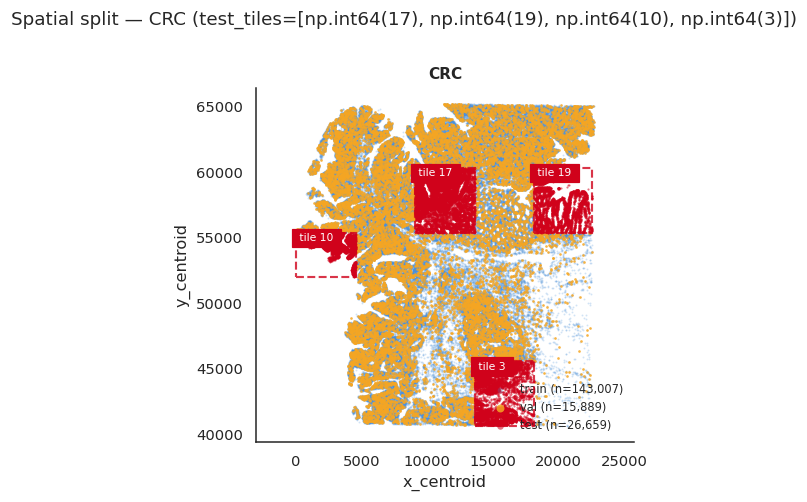

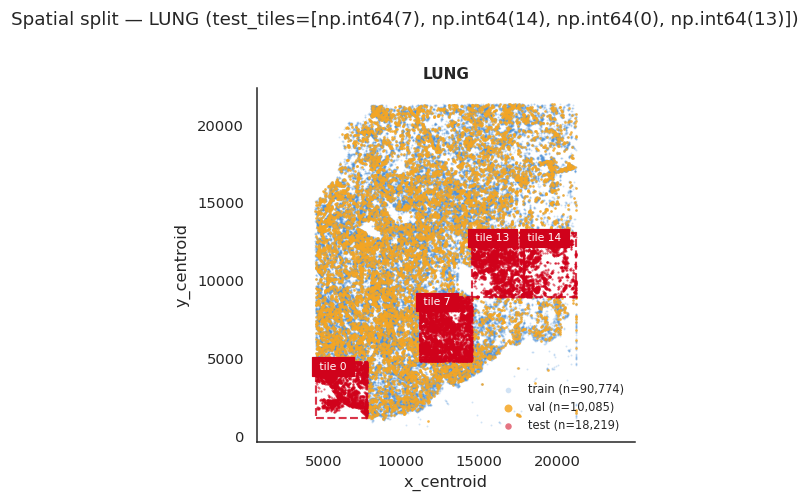

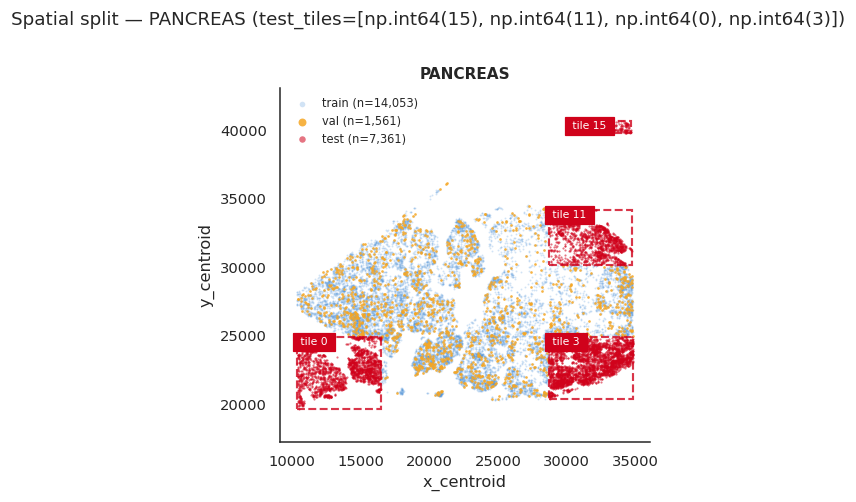

In [8]:
for name in ORDER:
    plot_spatial_layout(data[name])
    plt.show()


### Sanity check — cell counts per tile

A bar chart of cells per tile, with the held-out test tiles highlighted in red.
Useful for spotting whether the test tiles happen to be very small, very large, or otherwise non-representative.


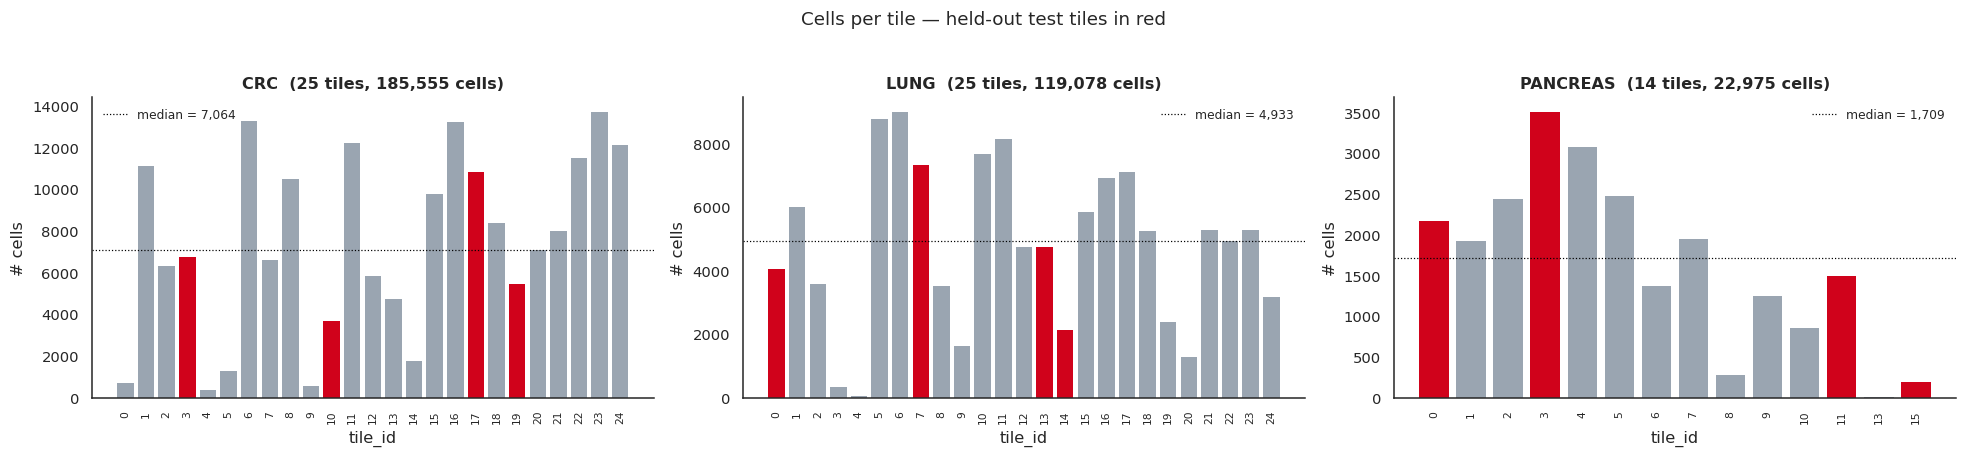

In [9]:
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), sharey=False)
if n == 1: axes = [axes]

for ax, name in zip(axes, datasets_with_df):
    d = data[name]
    if d['all_meta'] is None:
        ax.set_visible(False); continue

    meta = d['all_meta']
    counts = meta['tile_id'].value_counts().sort_index()
    test_set = set(int(t) for t in d['test_tiles'])
    colors = [SPLIT_COLOR['test'] if int(t) in test_set else '#9aa5b1' for t in counts.index]

    ax.bar(np.arange(len(counts)), counts.values, color=colors, edgecolor='none')
    ax.set_xticks(np.arange(len(counts)))
    ax.set_xticklabels(counts.index, rotation=90, fontsize=7)

    median_n = counts.median()
    ax.axhline(median_n, color='black', ls=':', lw=0.8,
               label=f'median = {int(median_n):,}')

    ax.set_xlabel('tile_id')
    ax.set_ylabel('# cells')
    ax.set_title(f'{name.upper()}  ({len(counts)} tiles, {len(meta):,} cells)')
    ax.legend(fontsize=8)

fig.suptitle('Cells per tile — held-out test tiles in red', y=1.03, fontsize=12)
fig.tight_layout()

if SAVE_FIGS:
    fig.savefig(FIG_DIR / 'cells_per_tile_3datasets.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / 'cells_per_tile_3datasets.png', bbox_inches='tight')
plt.show()


## Reading the results

Use this checklist when comparing the three datasets:

| Diagnostic | Healthy signal | Failure signal |
|---|---|---|
| Variance slope | `0.3 – 1.0` | `≤ 0` (model variance anti-correlates with biology) |
| Variance r | `> 0.5` | `≤ 0` |
| Mean slope | `≈ 1.0` | `≈ 0` (predictions collapse to a constant) |
| Mean MAE | small relative to true_mean range | comparable to or larger than true_mean range |
| Test tiles | dispersed across the slide(s) | clustered in one corner / one slide |
| Test tile size | similar to median tile | systematically tiny or huge |
| Cells per tile | roughly uniform | extreme imbalance affecting test tiles |

If a dataset fails most of the rows above, retraining with different hyperparameters is unlikely to help — the issue is likely upstream (data quality, sparsity, split, or cell segmentation).
